# Analysis 3 — Step 5: 발표 시각화

- (좌) M_content → M_content+channel **R² 점프** (4-Analysis 스파인 ⭐ A3)
- (우) **설명 vs 잔여 분산** → "절반의 천장" = A4(예측 시점) 피벗 근거
- **입력**: `step3_model_compare_channel.csv` · **산출**: `step5_fig_channel_r2.png`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False
PRIMARY, ACCENT, GRAY = "#3B4FE4", "#1A7F5A", "#C8CDD6"

In [2]:
cmp = pd.read_csv("step3_model_compare_channel.csv").set_index("model")
r2_content = cmp.loc["M_content", "rand_R2_test"]
r2_chan = cmp.loc["M_content+chan (OOF)", "rand_R2_test"]
cv_c = (cmp.loc["M_content", "cv_R2_mean"], cmp.loc["M_content", "cv_R2_std"])
cv_ch = (cmp.loc["M_content+chan (OOF)", "cv_R2_mean"], cmp.loc["M_content+chan (OOF)", "cv_R2_std"])
print(f"content CV R²={cv_c[0]:.3f}±{cv_c[1]:.3f} | +channel CV R²={cv_ch[0]:.3f}±{cv_ch[1]:.3f}")

content CV R²=0.107±0.017 | +channel CV R²=0.323±0.021


[저장] step5_fig_channel_r2.png


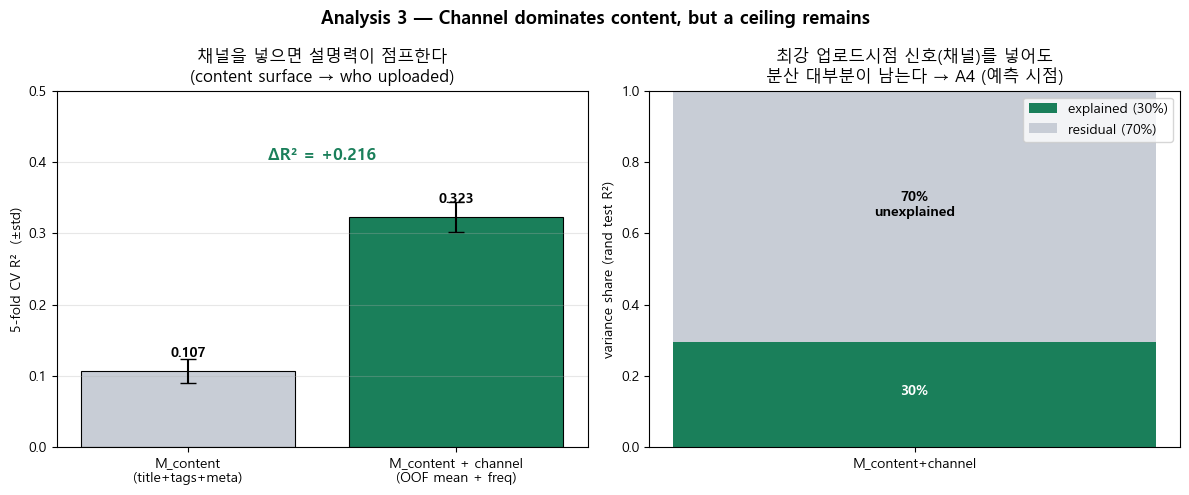

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (좌) R² 점프 — CV 평균±std
labels = ["M_content\n(title+tags+meta)", "M_content + channel\n(OOF mean + freq)"]
means, errs = [cv_c[0], cv_ch[0]], [cv_c[1], cv_ch[1]]
bars = ax1.bar(labels, means, yerr=errs, capsize=6, color=[GRAY, ACCENT], edgecolor="black", linewidth=0.8)
for bxr, m in zip(bars, means):
    ax1.text(bxr.get_x() + bxr.get_width()/2, m + 0.02, f"{m:.3f}", ha="center", fontweight="bold")
ax1.annotate(f"ΔR² = +{cv_ch[0]-cv_c[0]:.3f}", xy=(1, cv_ch[0]), xytext=(0.5, cv_ch[0]+0.08),
             ha="center", color=ACCENT, fontweight="bold", fontsize=12)
ax1.set_ylabel("5-fold CV R²  (±std)"); ax1.set_ylim(0, 0.5)
ax1.set_title("채널을 넣으면 설명력이 점프한다\n(content surface → who uploaded)")
ax1.grid(axis="y", alpha=0.3)

# (우) 설명 vs 잔여 — A4 피벗
explained, residual = r2_chan, 1 - r2_chan
ax2.bar(["M_content+channel"], [explained], color=ACCENT, label=f"explained ({explained:.0%})")
ax2.bar(["M_content+channel"], [residual], bottom=[explained], color=GRAY, label=f"residual ({residual:.0%})")
ax2.text(0, explained/2, f"{explained:.0%}", ha="center", color="white", fontweight="bold")
ax2.text(0, explained + residual/2, f"{residual:.0%}\nunexplained", ha="center", fontweight="bold")
ax2.set_ylabel("variance share (rand test R²)"); ax2.set_ylim(0, 1)
ax2.set_title("최강 업로드시점 신호(채널)를 넣어도\n분산 대부분이 남는다 → A4 (예측 시점)")
ax2.legend(loc="upper right")

fig.suptitle("Analysis 3 — Channel dominates content, but a ceiling remains", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("step5_fig_channel_r2.png", dpi=200)
print("[저장] step5_fig_channel_r2.png")
plt.show()

## 점검 메모

- 좌: CV R² 0.107 → 0.323 (ΔR²=+0.216). 우: 설명 30% / 잔여 70%.
- 발표 서사: "채널이 콘텐츠를 이긴다(강) → 그래도 70% 미설명(천장) → A4 예측 시점".